# Assignment 5
### Do all four questions.

## Question 1

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [71]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [72]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [73]:
A1= A@e_1
A1

array([1, 4, 7])

In [74]:
A2=A@e_2
A2

array([2, 5, 8])

In [75]:
A3=A@e_3
A3

array([3, 6, 9])

The first element in each row gets selected when doing A times e_1. Since each row is mutiplied by the columns. The first elements are mutiplied together, the middle elements are multiplied together, and the third items are multipled together and the prodcuts are added. Since the last two elements are 0 there second and third elements are 0, so the total is just the first elements mutiplied by 1. The position of the 1 changes to the middle in e_2, so the matrix product is all the middle elements. The position of the 1 then moves to the third position in e_3, so the matrix product is all the third elements.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [76]:
u = np.ones(3)

In [77]:
Au=A@u
Au

array([ 6., 15., 24.])

Each row in the vector gets multiplied by the ones vector. Each number is thr row is multiplied by one and then the numbers in each row added together. So the sum of each row will be the number for the corresponding column.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [78]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])


In [79]:
Ax=A@x
Ax

array([-2,  4, 11])

The matrix product is the same as the matrix x. Each row in the identity matrix on multiplied by x. Since there is only a one and two zeros in each column, only the number in x that remains is the one that matches the correspoding column. In the identiy matrix since the diagnol is all ones we just get the same matrix back.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [80]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])


In [81]:
Ax=A@x
Ax

array([11, -2,  4])

This is similar to the identiy matrix where the zeros cancel out two numbers in each column, so only the number multiplied by the one remains. Since the position of the one is diffrent, the numbers will be in different oder.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [82]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
print(A)
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.83498163 0.59655403 0.28886324]
 [0.04295157 0.9736544  0.5964717 ]
 [0.79026316 0.91033938 0.68815445]]
[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [83]:
Ae1=A@e_1
print(Ae1)
Ae2=A@e_2
print(Ae2)
Ae3=A@e_3
print(Ae3)

[0.50052958 0.02574731 0.47372311]
[0.24049286 0.39251588 0.36699127]
[0.18358131 0.37907577 0.43734292]


In [84]:
e_1

array([1, 0, 0])

In [85]:
e_2

array([0, 1, 0])

Each matrix product is the column probabilties. Each column in the vector is multiplied by the e vectors. Since where the one is changes, the products go from the first to second to the third column. Each product adds to one.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [86]:
e_1 * (A**5)

array([[3.14158455e-02, 0.00000000e+00, 0.00000000e+00],
       [1.13151261e-08, 0.00000000e+00, 0.00000000e+00],
       [2.38573852e-02, 0.00000000e+00, 0.00000000e+00]])

In [87]:
e_2 * (A**5)

array([[0.        , 0.00080447, 0.        ],
       [0.        , 0.00931722, 0.        ],
       [0.        , 0.006657  , 0.        ]])

In [88]:
e_3 * (A**5)

array([[0.        , 0.        , 0.00020852],
       [0.        , 0.        , 0.00782763],
       [0.        , 0.        , 0.01599965]])

All the numbers in the get closer to the zero as we multiply by A more times.

## Question 2

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [89]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [90]:
inital_cond=np.array([1,0])
inital_cond

array([1, 0])

In [91]:
p_1=T@inital_cond
p_1

array([0.25, 0.75])

Going from state 1 to state 1 has a probabilty of 0.25, while going from state 1 to state 2 has a probability of 0.75.

In [92]:
p_2= T @ p_1
p_2

array([0.4375, 0.5625])

This is a forcast of the probabities of state 1 vs state 2 two periods after starting at the intial condition [1,0].

In [93]:
n=100
p=np.array([1,0])
for t in range(n):
    print(p)
    p=T@p

[1 0]
[0.25 0.75]
[0.4375 0.5625]
[0.390625 0.609375]
[0.40234375 0.59765625]
[0.39941406 0.60058594]
[0.40014648 0.59985352]
[0.39996338 0.60003662]
[0.40000916 0.59999084]
[0.39999771 0.60000229]
[0.40000057 0.59999943]
[0.39999986 0.60000014]
[0.40000004 0.59999996]
[0.39999999 0.60000001]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0

The probabilty of state 1 and state 2 start to stabilize  around period 15.

In [94]:
n=100
p=np.array([0,1])
for t in range(n):
    print(p)
    p=T@p

[0 1]
[0.5 0.5]
[0.375 0.625]
[0.40625 0.59375]
[0.3984375 0.6015625]
[0.40039062 0.59960938]
[0.39990234 0.60009766]
[0.40002441 0.59997559]
[0.3999939 0.6000061]
[0.40000153 0.59999847]
[0.39999962 0.60000038]
[0.4000001 0.5999999]
[0.39999998 0.60000002]
[0.40000001 0.59999999]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6

Both starting conditions eventually coverege to a proabilty of 0.4 for state 1 and 0.6 for state 2. This shows that starting conditions cannot tell me much about what is happening far in the future.

In [95]:
n=100
state=0
sim=[]
for t in range(n):
    sim.append(state)
    prob=T[:,state]
    state=np.random.choice([0,1],p=prob)

In [96]:
x=np.array(sim)
np.mean(x)

np.float64(0.61)

## Question 3

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [98]:
weather=pd.read_csv('cville_weather.csv')
print(weather['PRCP'].isna().value_counts())

PRCP
False    399
True      12
Name: count, dtype: int64


There are some missing values in precipiation.

In [99]:
weather['rain']=np.where(weather['PRCP']>0,1,0)


In [100]:
mean_rain=weather['rain'].mean()
mean_rain

np.float64(0.43552311435523117)

In [101]:
mean_sunny= 1 - mean_rain
mean_sunny

np.float64(0.5644768856447688)

In [102]:
sequence=weather['rain'].values


In [103]:
states=np.unique(sequence)
states

array([0, 1])

In [104]:
states=list(states)

In [105]:
S=len(states)
T=len(sequence)
tr_counts=np.zeros( (S,S) )
for t in range(1,T):
    x_t1=sequence[t-1]
    x_t=sequence[t]
    index_from = states.index(x_t1)
    index_to = states.index(x_t)
    tr_counts[index_from,index_to] +=1
print(tr_counts)


[[169.  62.]
 [ 63. 116.]]


In [106]:
rowsums=tr_counts.sum(axis=1,keepdims=True)
rowsums

array([[231.],
       [179.]])

In [107]:
states

[np.int64(0), np.int64(1)]

In [108]:
T=np.divide(tr_counts,rowsums,out=np.zeros_like(tr_counts), 
                            where=rowsums!=0)
T

array([[0.73160173, 0.26839827],
       [0.35195531, 0.64804469]])

- If it rained yestesday, there is a 64% chance it will rain today.
- If it didn't rain yestearday. there is a 27% chance it will rain today.

In [109]:
n=100
state=0
sim=[]
for t in range(n):
    sim.append(state)
    prob=T[state,:]
    state=np.random.choice([0,1],p=prob)


In [110]:
n=100
print('Sunny at Start')
p=np.array([1,0])
for t in range(n):
    print(p)
    p= p @ T

Sunny at Start
[1 0]
[0.73160173 0.26839827]
[0.62970529 0.37029471]
[0.59102067 0.40897933]
[0.57633419 0.42366581]
[0.57075852 0.42924148]
[0.56864174 0.43135826]
[0.56783811 0.43216189]
[0.56753302 0.43246698]
[0.56741719 0.43258281]
[0.56737321 0.43262679]
[0.56735652 0.43264348]
[0.56735018 0.43264982]
[0.56734777 0.43265223]
[0.56734686 0.43265314]
[0.56734651 0.43265349]
[0.56734638 0.43265362]
[0.56734633 0.43265367]
[0.56734631 0.43265369]
[0.56734631 0.43265369]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326

In [111]:
n=100
print('Rainy at Start')
p=np.array([0,1])
for t in range(n):
    print(p)
    p= p @ T

Rainy at Start
[0 1]
[0.35195531 0.64804469]
[0.48557388 0.51442612]
[0.5363017 0.4636983]
[0.55556033 0.44443967]
[0.5628718 0.4371282]
[0.56564757 0.43435243]
[0.56670139 0.43329861]
[0.56710146 0.43289854]
[0.56725335 0.43274665]
[0.56731101 0.43268899]
[0.5673329 0.4326671]
[0.56734122 0.43265878]
[0.56734437 0.43265563]
[0.56734557 0.43265443]
[0.56734602 0.43265398]
[0.5673462 0.4326538]
[0.56734626 0.43265374]
[0.56734629 0.43265371]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.56

No matter where we start, it takes about 20 times for the matrix to converge tp a fixed probability.

<Axes: xlabel='PRCP', ylabel='Density'>

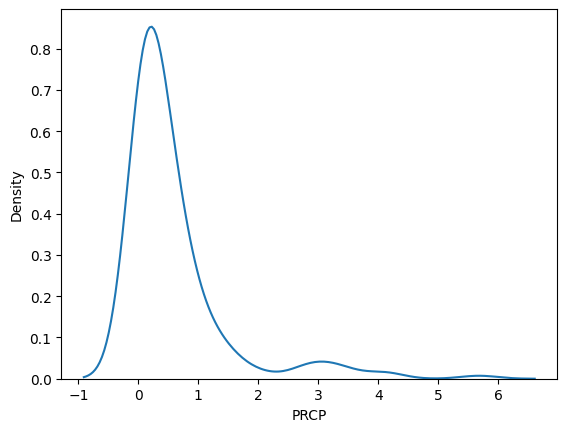

In [116]:
sns.kdeplot( x = weather.loc[ weather['PRCP']>0, 'PRCP'])

We could included more factors like temperature, season, etc to create a more accurate model for forecasting.

## Question 4

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [43]:
import pickle

In [44]:
with open('/Users/graceegeorge/DS5030_public_repo/taxicab.pkl','rb') as file:
   data=pickle.load(file)
len(data)


1000

In [47]:
states=set()
for i in range(1,len(data)):
    new_trip=set(data[i])
    new_states=set(new_trip)
    states=states.union(new_states)
len(states) 


38

In [48]:
T=np.array((len(states),len(states)))
states=list(states)

In [49]:
tr_counts=np.zeros((len(states),len(states)))
for trip in data:
    seq=np.array(trip)
    for t in range(1,len(seq)):
        x_t1=seq[t-1]
        x_t=seq[t]
        index_from = states.index(x_t1)
        index_to = states.index(x_t)
        tr_counts[index_from,index_to] +=1

In [50]:
tr_counts

array([[2.424690e+05, 6.924100e+04, 2.328000e+03, ..., 1.245500e+04,
        1.701000e+03, 1.239190e+05],
       [6.457900e+04, 1.389343e+06, 2.636500e+04, ..., 1.658810e+05,
        4.305000e+03, 2.781910e+05],
       [1.933000e+03, 3.155600e+04, 7.192200e+04, ..., 3.101000e+03,
        1.710000e+02, 6.406000e+03],
       ...,
       [1.080900e+04, 1.686320e+05, 3.778000e+03, ..., 1.280130e+05,
        9.050000e+02, 3.819700e+04],
       [2.213000e+03, 3.941000e+03, 2.090000e+02, ..., 8.830000e+02,
        5.493000e+03, 2.917000e+03],
       [1.225440e+05, 2.604200e+05, 7.742000e+03, ..., 4.193900e+04,
        2.911000e+03, 6.623970e+05]], shape=(38, 38))

In [51]:
rowsums=tr_counts.sum(axis=0,keepdims=True)
rowsums


array([[8.393620e+05, 3.851929e+06, 3.168490e+05, 5.017430e+05,
        1.058730e+05, 3.603000e+03, 1.000000e+00, 3.705660e+05,
        5.077760e+05, 2.292330e+05, 7.253000e+04, 3.000000e+00,
        1.224325e+06, 4.930000e+02, 8.740550e+05, 3.701250e+05,
        1.627050e+05, 1.803491e+06, 1.063770e+05, 3.859100e+04,
        1.200000e+01, 8.886440e+05, 1.431200e+04, 2.797713e+06,
        2.171620e+05, 4.415950e+05, 1.743220e+05, 8.010000e+03,
        1.038800e+04, 5.102620e+05, 1.112860e+05, 3.952740e+05,
        2.363961e+06, 4.086400e+05, 5.505970e+05, 6.543970e+05,
        5.790800e+04, 1.978283e+06]])

In [55]:
T=np.divide(tr_counts,rowsums,out=np.zeros_like(tr_counts), 
                            where=rowsums!=0)
T

array([[0.28887298, 0.01797567, 0.00734735, ..., 0.01903279, 0.02937418,
        0.06263967],
       [0.0769382 , 0.36068759, 0.08320998, ..., 0.2534868 , 0.07434206,
        0.14062245],
       [0.00230294, 0.00819226, 0.22699141, ..., 0.00473871, 0.00295296,
        0.00323816],
       ...,
       [0.01287764, 0.04377858, 0.01192366, ..., 0.19561978, 0.01562824,
        0.01930816],
       [0.00263653, 0.00102312, 0.00065962, ..., 0.00134933, 0.09485736,
        0.00147451],
       [0.1459966 , 0.06760768, 0.02443435, ..., 0.06408801, 0.05026939,
        0.3348343 ]], shape=(38, 38))

In [52]:
import pandas as pd

In [56]:
pd.DataFrame(np.round(T,2), index=states, columns=states)

,West Village,Midtown,East Harlem,Gramercy,Chinatown,Randall's Island,Liberty Island,Lower East Side,Kips Bay,Battery Park City,...,Two Bridges,Greenwich Village,Stuyvesant Town,Flatiron District,Outside Manhattan,Tribeca,SoHo,Murray Hill,Civic Center,Chelsea
West Village,0.29,0.02,0.01,0.03,0.03,0.01,0.0,0.03,0.02,0.05,...,0.02,0.08,0.02,0.04,0.02,0.06,0.07,0.02,0.03,0.06
Midtown,0.08,0.36,0.08,0.14,0.06,0.07,0.0,0.06,0.18,0.08,...,0.08,0.10,0.11,0.20,0.09,0.07,0.08,0.25,0.07,0.14
East Harlem,0.00,0.01,0.23,0.00,0.00,0.08,0.0,0.00,0.01,0.00,...,0.01,0.00,0.01,0.00,0.01,0.00,0.00,0.00,0.00,0.00
Gramercy,0.02,0.02,0.01,0.18,0.02,0.01,0.0,0.02,0.06,0.01,...,0.02,0.04,0.07,0.04,0.01,0.01,0.02,0.04,0.02,0.03
Chinatown,0.00,0.00,0.00,0.00,0.13,0.00,0.0,0.03,0.00,0.01,...,0.03,0.00,0.01,0.00,0.00,0.01,0.01,0.00,0.05,0.00
Randall's Island,0.00,0.00,0.00,0.00,0.00,0.18,0.0,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Liberty Island,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Lower East Side,0.01,0.01,0.01,0.03,0.06,0.01,0.0,0.21,0.02,0.01,...,0.06,0.02,0.03,0.01,0.02,0.01,0.02,0.01,0.02,0.01
Kips Bay,0.01,0.02,0.01,0.05,0.01,0.01,0.0,0.02,0.19,0.01,...,0.02,0.02,0.05,0.04,0.01,0.01,0.01,0.07,0.01,0.02
Battery Park City,0.02,0.00,0.00,0.00,0.01,0.00,0.0,0.01,0.00,0.26,...,0.02,0.01,0.01,0.01,0.01,0.07,0.02,0.00,0.02,0.01


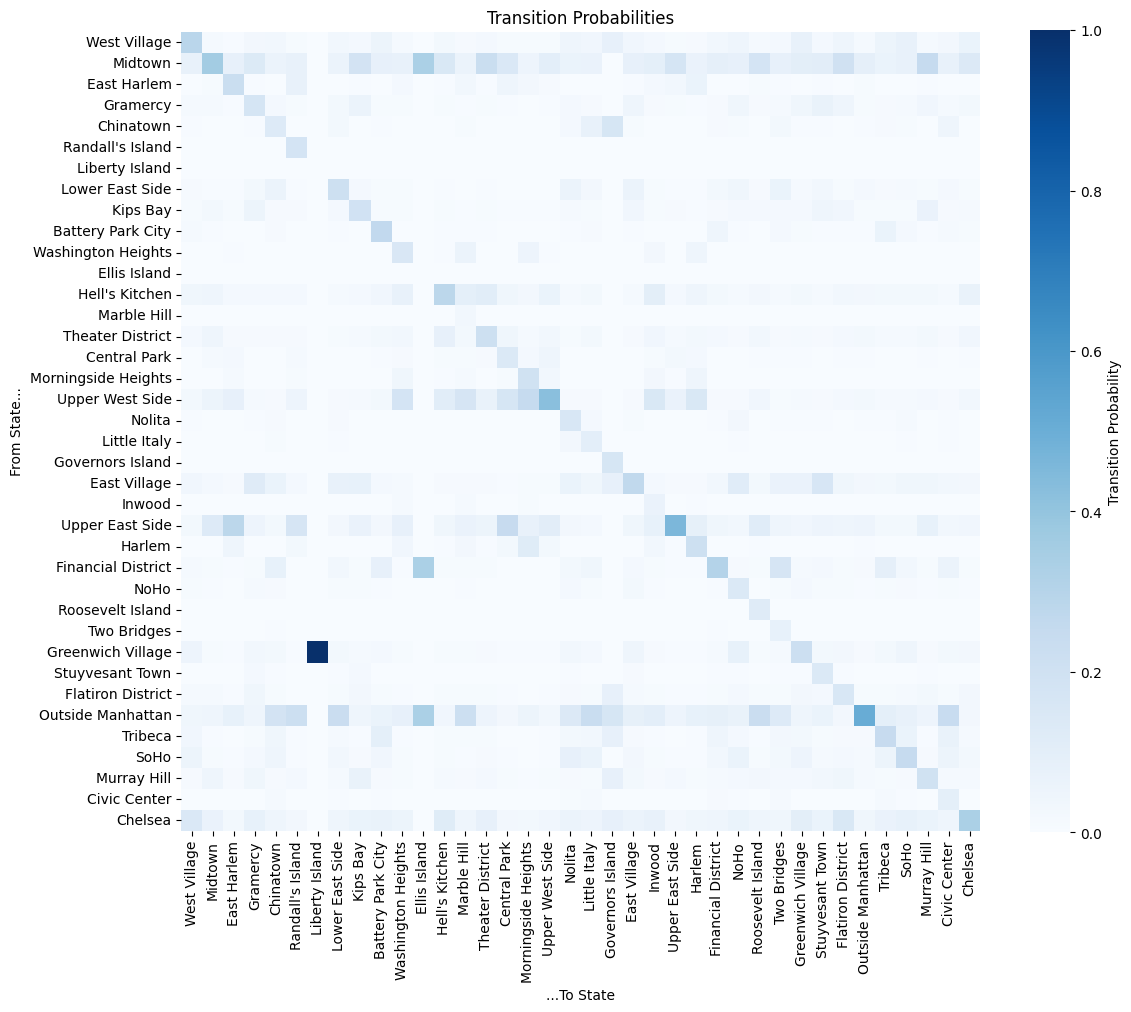

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(T, 
            cmap='Blues',       # Or 'Blues', 'plasma', whatever looks good
            square=True,          # Keep cells square
            xticklabels=states,
            yticklabels=states,
            cbar_kws={'label': 'Transition Probability'})

plt.title('Transition Probabilities')
plt.xlabel('...To State')
plt.ylabel('From State...')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

From this heat map, the most common route if from Greenwich Village to  Liberty Island. The diaganal accross the heatmap is very dense, which suggests that taxis commonly take people around the same neigbhoorhood.

Taxis are more likely to be order one rather than order two or more because the previous ride affects the next ride more that the one two rides before. If a taxi goes from East Village to SoHo, the taxi cab is already in SoHo so will likely pick up another passenger in the area. Futures rides from that one don't really depend on the first ride but where the previous ride ended up.

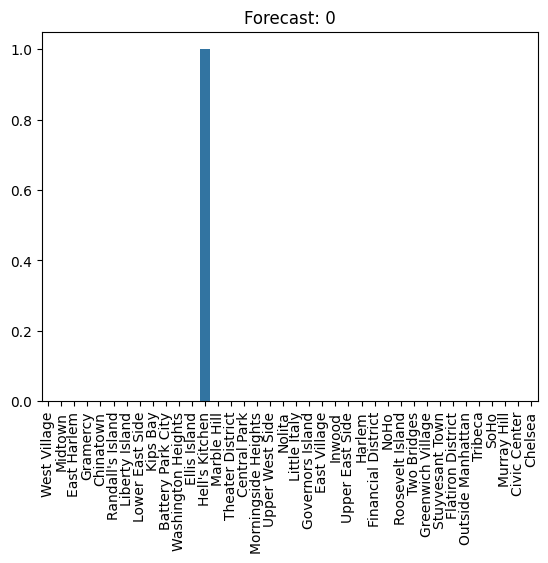

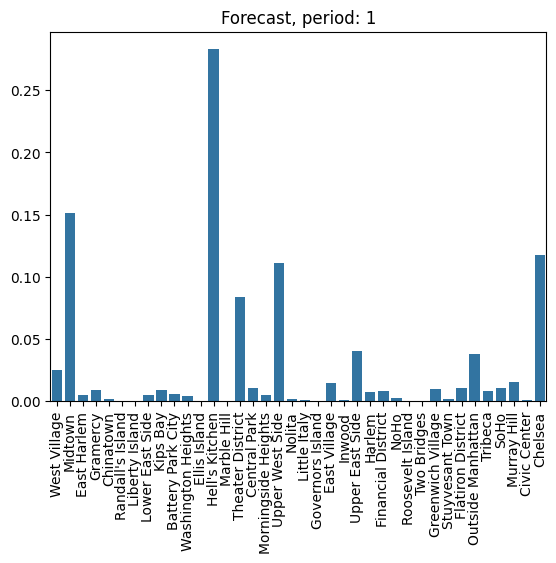

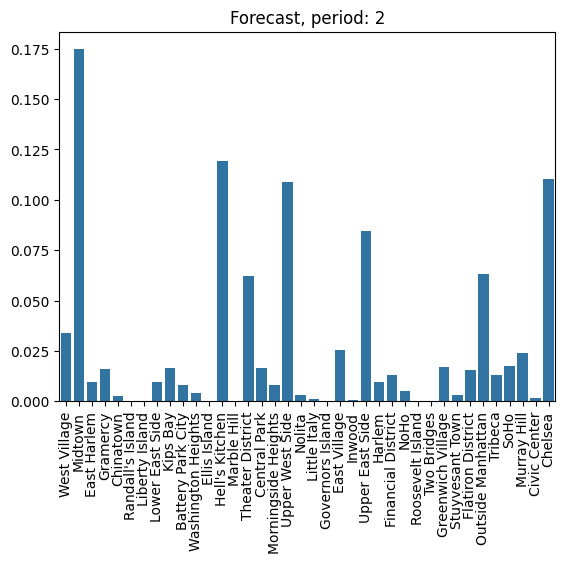

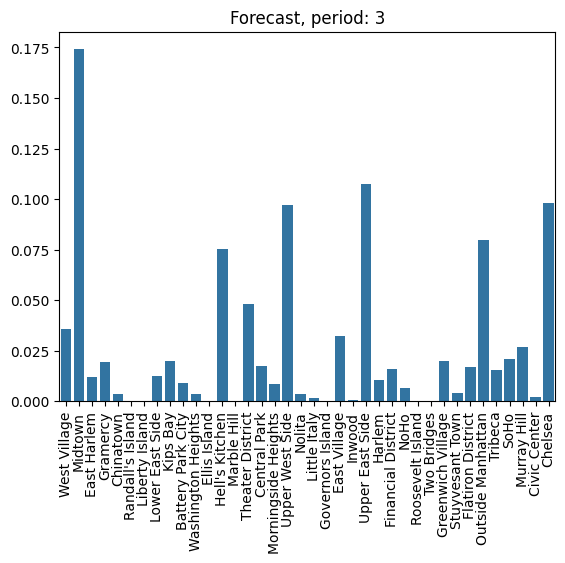

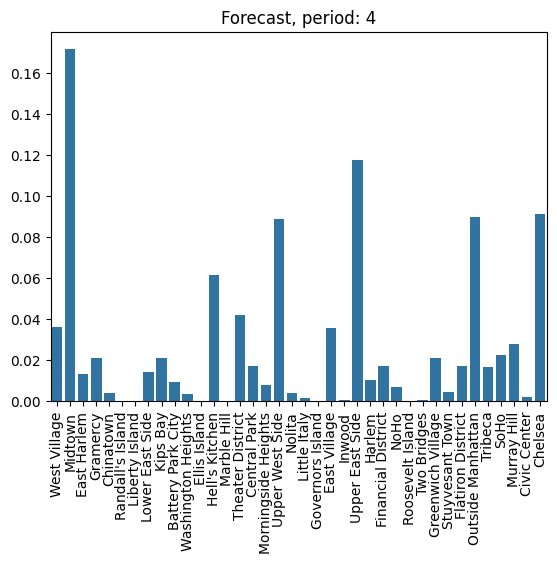

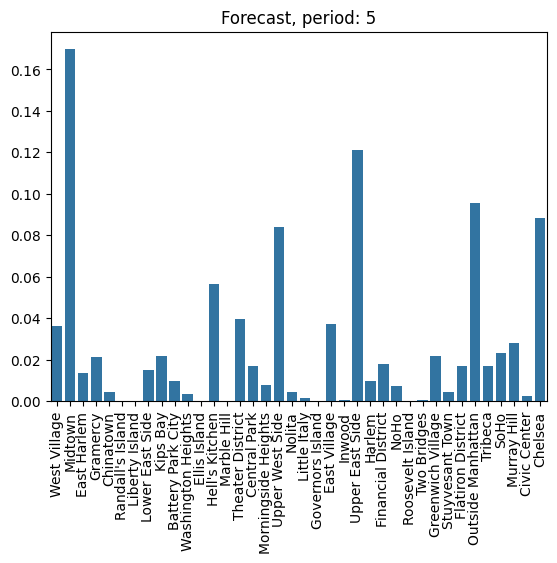

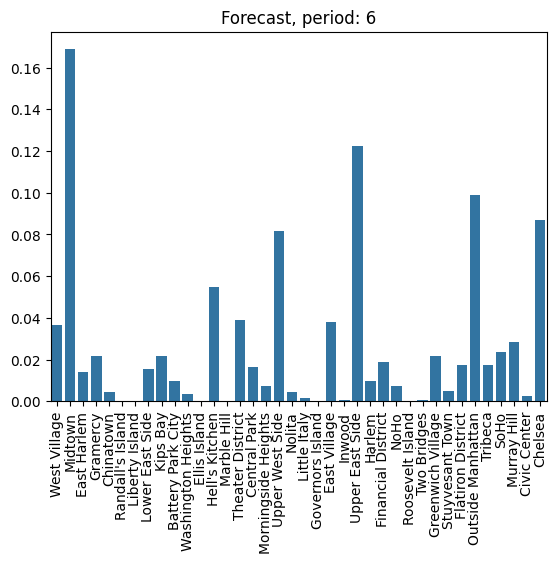

In [67]:
initial_state ="Hell's Kitchen"
state_index = states.index(initial_state)
density=np.zeros(len(states))
density[state_index]=1
sns.barplot(x=states,y=density).set(title=f'Forecast: 0')
plt.xticks(rotation=90)
plt.show()

forecast = [initial_state]
for t in range(6): 
    density = T @ density
    forecast.append(density) # Append new forecast
  
    sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(t+1)}')
    plt.xticks(rotation=90)
    plt.show()

After around 5 periods, the proabability of going to each neighborhood become stable.

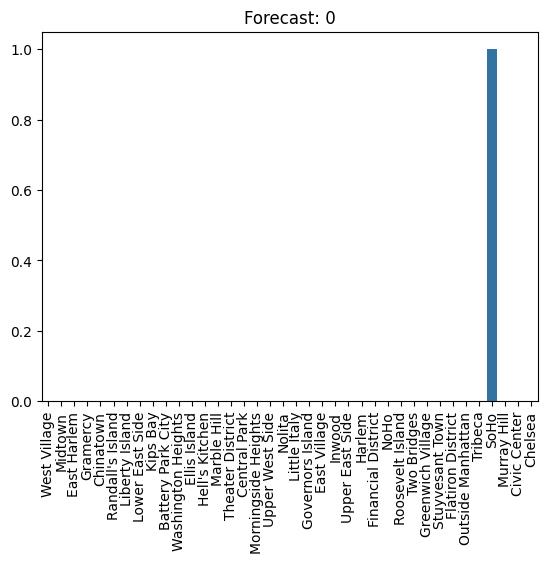

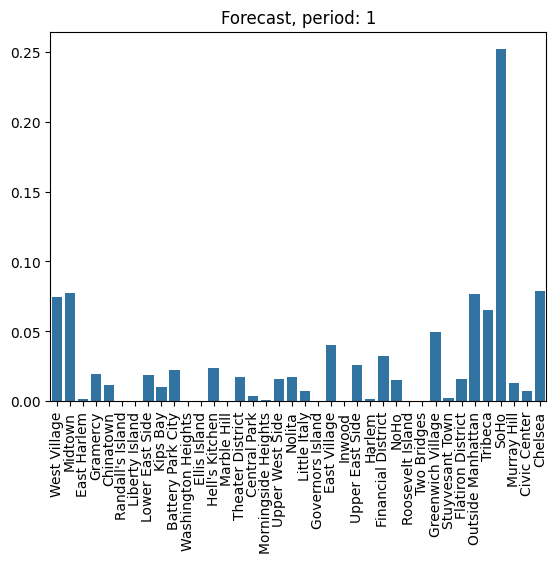

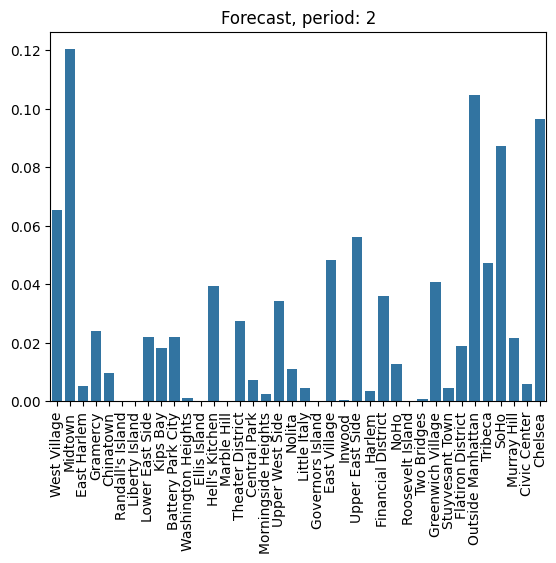

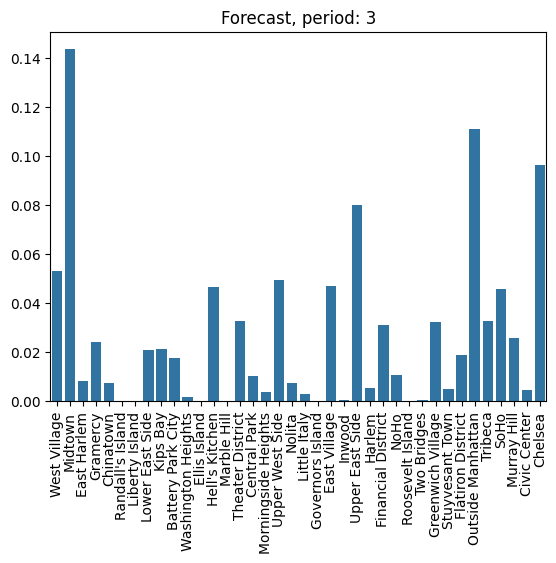

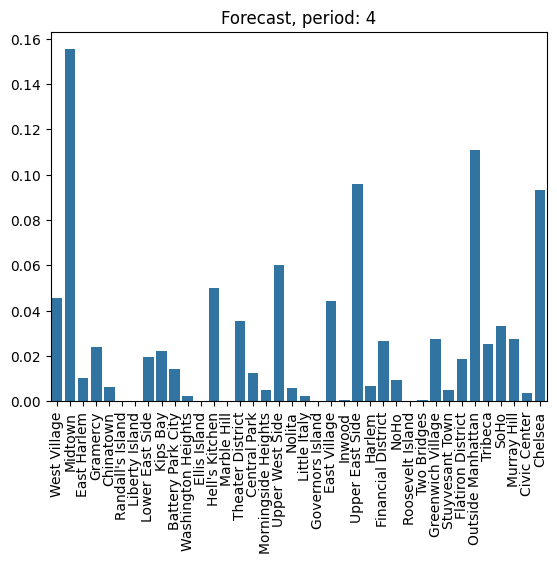

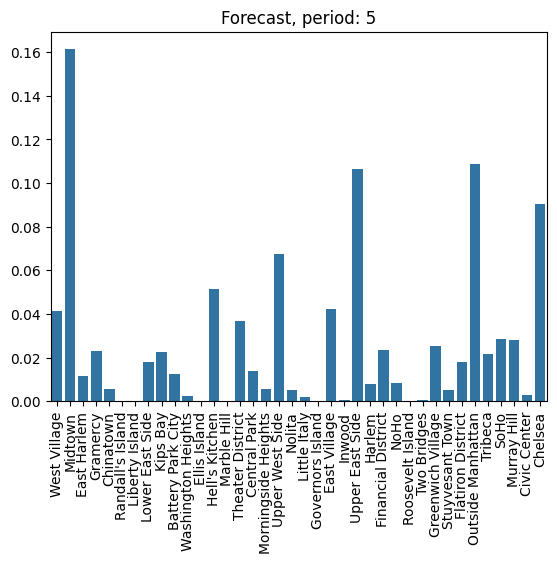

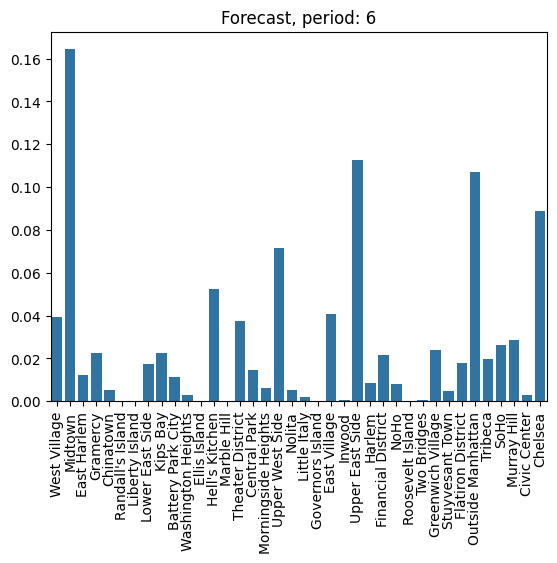

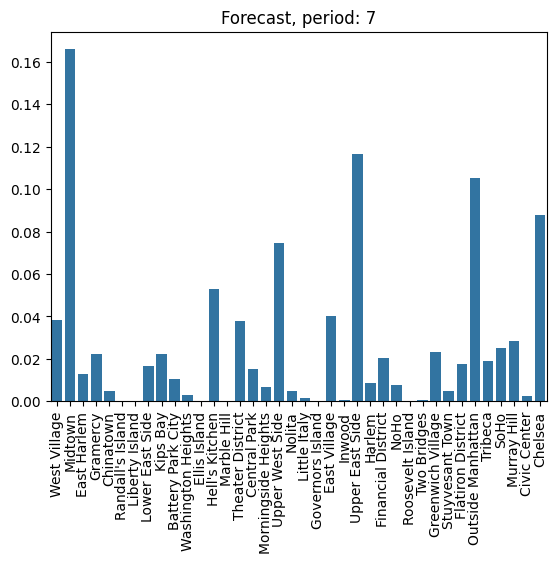

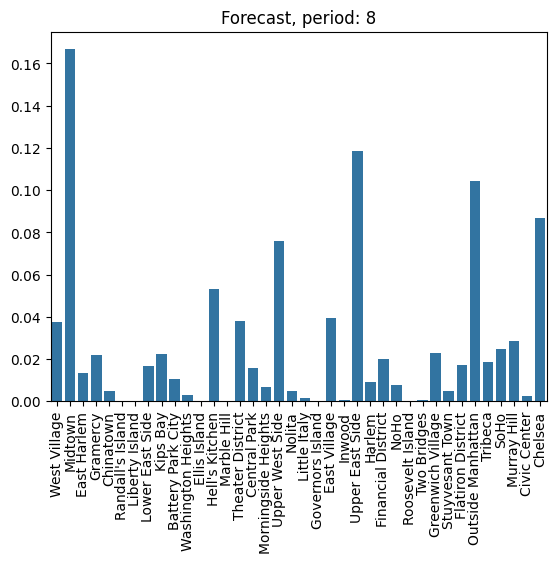

In [69]:
initial_state ="SoHo"
state_index = states.index(initial_state)
density=np.zeros(len(states))
density[state_index]=1
density

sns.barplot(x=states,y=density).set(title=f'Forecast: 0')
plt.xticks(rotation=90)
plt.show()

forecast = [initial_state]
for t in range(8): 
    density = T @ density
    forecast.append(density) # Append new forecast
  
    sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(t+1)}')
    plt.xticks(rotation=90)
    plt.show()

The cabs spend most of their time in Midtown, Upper East Side, Outside Manhattan, or Chelsea regardless of where the starting position is.